<a href="https://colab.research.google.com/github/NhiLY120504/EcommerceRepurchasePrediction_ML/blob/main/RepurchasePrediction-CategoryRecommendation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from google.colab import drive
import os

# Kết nối Google Colab với Google Drive
print("xác thực tài khoản gg drive")
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/KLTN_dataset'

# Liệt kê các file trong thư mục để kiểm tra
print(f"\nCác file trong thư mục '{drive_path}':")
try:
    for file in os.listdir(drive_path):
        print(file)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy thư mục")

xác thực tài khoản gg drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Các file trong thư mục '/content/drive/MyDrive/KLTN_dataset':
apparel_transactions.csv
apparel_clickstream.csv
apparel_products.csv
apparel_customers.csv


In [5]:
import pandas as pd
from google.colab import drive
import os

# Bước 1: Kết nối Colab với Google Drive
print("Đang kết nối Google Drive...")
drive.mount('/content/drive')
print("Kết nối thành công.")

# Bước 2: Xác định đường dẫn thư mục chứa các file
drive_path = '/content/drive/MyDrive/KLTN_dataset'

# Bước 3: Đọc các file CSV và kiểm tra thông tin chung
try:
    # Đọc 4 file CSV vào các DataFrame
    print("\nĐang đọc dữ liệu từ các file CSV...")
    df_clickstream = pd.read_csv(os.path.join(drive_path, 'apparel_clickstream.csv'))
    df_customers = pd.read_csv(os.path.join(drive_path, 'apparel_customers.csv'))
    df_products = pd.read_csv(os.path.join(drive_path, 'apparel_products.csv'))
    df_transactions = pd.read_csv(os.path.join(drive_path, 'apparel_transactions.csv'))
    print("Hoàn tất đọc dữ liệu.")

    # Kiểm tra thông tin chung của từng DataFrame

    # 1. Bảng Click Stream
    print("\n--- Thông tin bảng Click Stream ---")
    print("Kích thước bảng:", df_clickstream.shape)
    print("\nThông tin chi tiết các cột:")
    df_clickstream.info()
    print("\n5 dòng đầu tiên:")
    print(df_clickstream.head())

    # 2. Bảng Customers
    print("\n\n--- Thông tin bảng Customers ---")
    print("Kích thước bảng:", df_customers.shape)
    print("\nThông tin chi tiết các cột:")
    df_customers.info()
    print("\n5 dòng đầu tiên:")
    print(df_customers.head())

    # 3. Bảng Products
    print("\n\n--- Thông tin bảng Products ---")
    print("Kích thước bảng:", df_products.shape)
    print("\nThông tin chi tiết các cột:")
    df_products.info()
    print("\n5 dòng đầu tiên:")
    print(df_products.head())

    # 4. Bảng Transactions
    print("\n\n--- Thông tin bảng Transactions ---")
    print("Kích thước bảng:", df_transactions.shape)
    print("\nThông tin chi tiết các cột:")
    df_transactions.info()
    print("\n5 dòng đầu tiên:")
    print(df_transactions.head())

except FileNotFoundError as e:
    print("\nLỗi: Không tìm thấy file tại đường dẫn. Vui lòng kiểm tra lại tên file và đường dẫn.")
    print(f"Chi tiết lỗi: {e}")
except Exception as e:
    print(f"\nMột lỗi đã xảy ra: {e}")

Đang kết nối Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kết nối thành công.

Đang đọc dữ liệu từ các file CSV...
Hoàn tất đọc dữ liệu.

--- Thông tin bảng Click Stream ---
Kích thước bảng: (6948248, 7)

Thông tin chi tiết các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6948248 entries, 0 to 6948247
Data columns (total 7 columns):
 #   Column                Dtype  
---  ------                -----  
 0   session_id            object 
 1   event_name            object 
 2   event_time            object 
 3   event_id              object 
 4   traffic_source        object 
 5   event_metadata        object 
 6   product_id_extracted  float64
dtypes: float64(1), object(6)
memory usage: 371.1+ MB

5 dòng đầu tiên:
                             session_id   event_name  \
0  f7b5cd60-4f87-4b3c-8bde-c7da8930eec2     HOMEPAGE   
1  f7b5cd60-4f87-4b3c-8bde-c7da8930eec2  ADD_TO_CART   


<Figure size 1200x600 with 0 Axes>

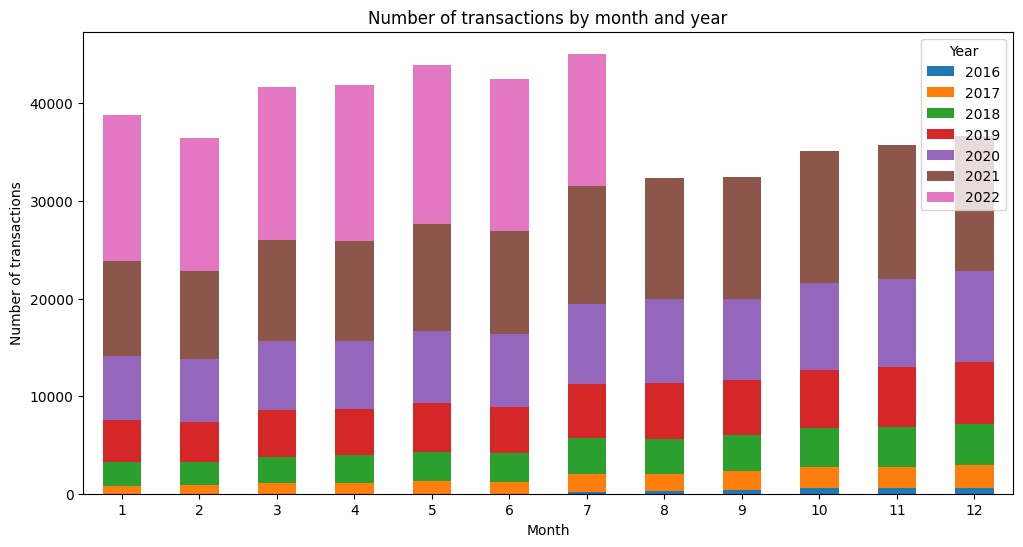

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chuyển đổi created_at sang định dạng datetime
df_transactions['created_at'] = pd.to_datetime(df_transactions['created_at'])

# Phân tích giao dịch theo năm và tháng
df_transactions['year'] = df_transactions['created_at'].dt.year
df_transactions['month'] = df_transactions['created_at'].dt.month
transactions_by_month = df_transactions.groupby(['year', 'month']).size().reset_index(name='count')

# --- Biểu đồ: Số lượng giao dịch theo tháng và năm ---
# Tạo pivot table để chuẩn bị dữ liệu cho biểu đồ cột chồng
transactions_pivot = transactions_by_month.pivot(index='month', columns='year', values='count').fillna(0)

# Vẽ biểu đồ cột chồng
plt.figure(figsize=(12, 6))
transactions_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Number of transactions by month and year')
plt.xlabel('Month')
plt.ylabel('Number of transactions')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.show()


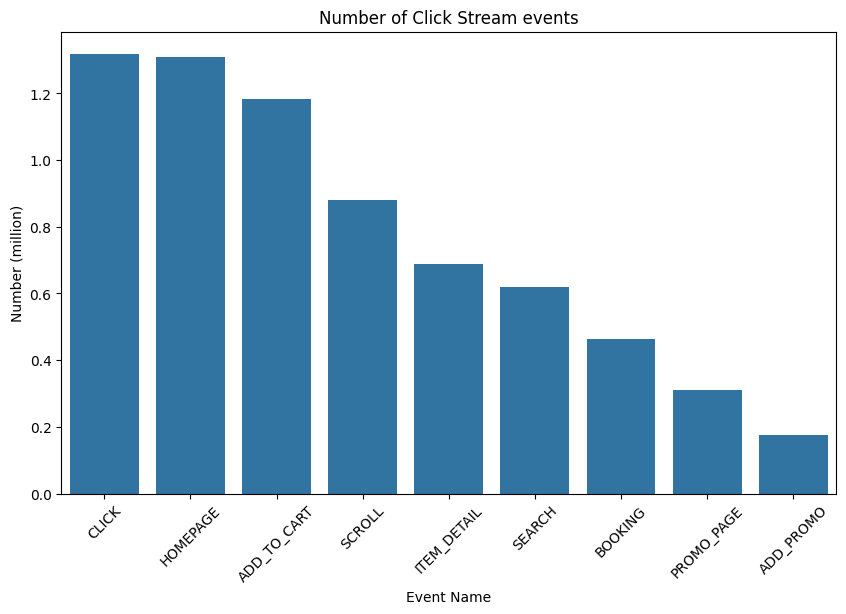

In [7]:
# Chuyển đổi event_time sang định dạng datetime
df_clickstream['event_time'] = pd.to_datetime(df_clickstream['event_time'])

# Phân tích các loại sự kiện
event_counts = df_clickstream['event_name'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=event_counts.index, y=event_counts.values)
plt.title('Number of Click Stream events')
plt.xlabel('Event Name')
plt.ylabel('Number (million)')
plt.xticks(rotation=45)

# Chuyển đổi nhãn trục y sang đơn vị million
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{x/1000000:.1f}'))

plt.show()

Peak booking hour: 23:00 (24,337 bookings)


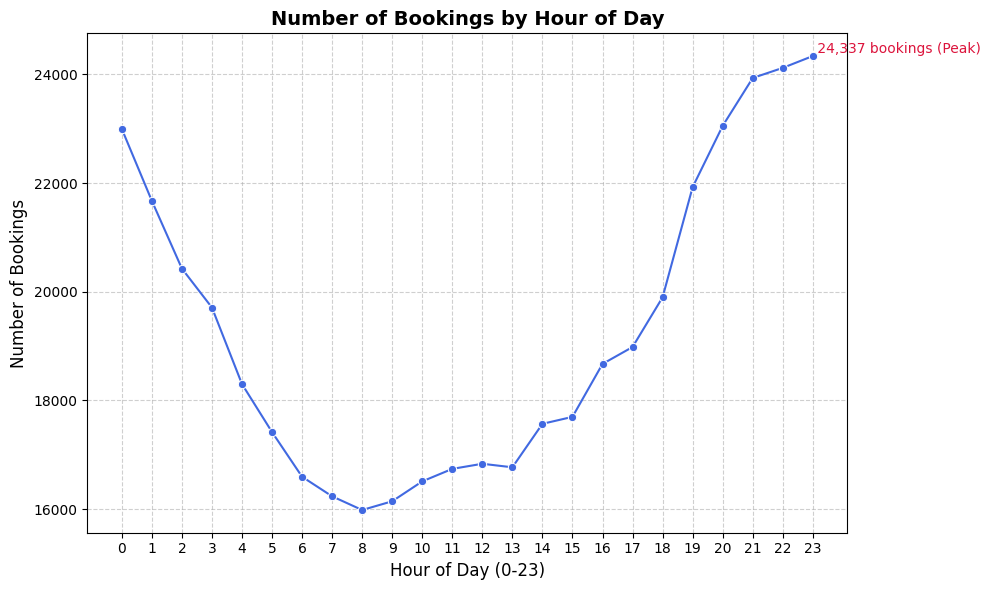

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clickstream['event_time'] = pd.to_datetime(df_clickstream['event_time'])

# Filter for "BOOKING" events
df_booking = df_clickstream[df_clickstream['event_name'] == 'BOOKING'].copy()

if not df_booking.empty:
    # Extract the hour from the timestamp
    df_booking['hour'] = df_booking['event_time'].dt.hour

    # Count bookings by hour
    booking_by_hour = df_booking['hour'].value_counts().sort_index()

    # Find the hour with the highest bookings
    peak_hour = booking_by_hour.idxmax()
    peak_count = booking_by_hour.max()

    print(f"Peak booking hour: {peak_hour}:00 ({peak_count:,} bookings)")

    # --- Line Chart ---
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=booking_by_hour.index, y=booking_by_hour.values, marker='o', color='royalblue')

    plt.title('Number of Bookings by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (0-23)', fontsize=12)
    plt.ylabel('Number of Bookings', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.6)

    # Annotate the peak value on the chart
    plt.text(
        peak_hour, peak_count,
        f' {peak_count:,} bookings (Peak)',
        fontsize=10,
        color='crimson',
        va='bottom'
    )

    plt.tight_layout()
    plt.show()

else:
    print("No 'BOOKING' events found in the data.")

Busiest Month: 7 (45,085 transactions)


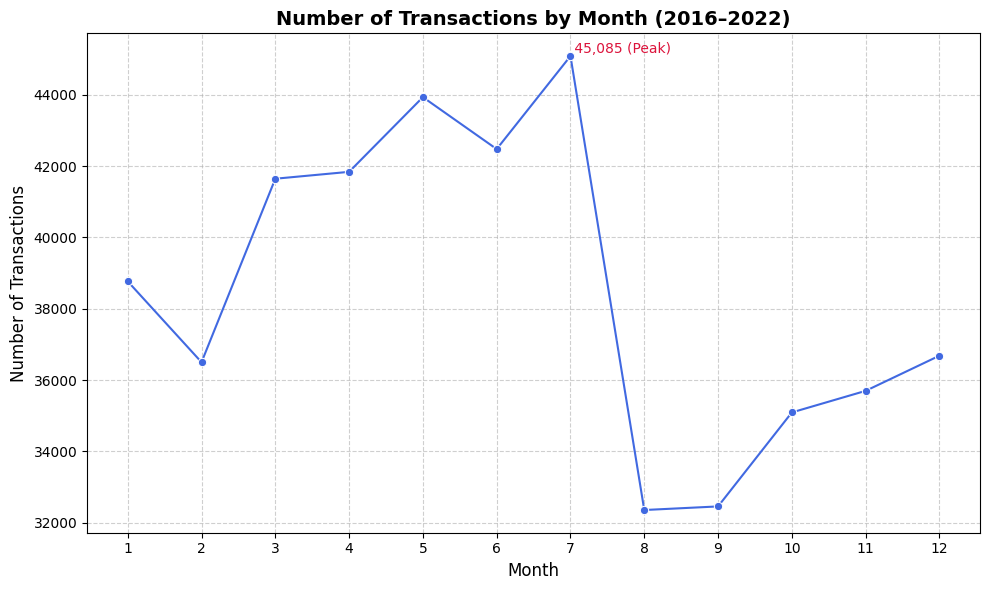

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure created_at is in datetime format
df_transactions['created_at'] = pd.to_datetime(df_transactions['created_at'])
df_transactions['month'] = df_transactions['created_at'].dt.month

# Count transactions by month (period 2016–2022)
monthly_transactions = df_transactions['month'].value_counts().sort_index()

# Find the month with the highest number of transactions
most_active_month = monthly_transactions.idxmax()
peak_value = monthly_transactions.max()

print(f"Busiest Month: {most_active_month} ({peak_value:,} transactions)")

# --- Line Chart ---
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_transactions.index, y=monthly_transactions.values, marker='o', color='royalblue')

plt.title('Number of Transactions by Month (2016–2022)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Display ticks 1-12
plt.xticks(ticks=range(1, 13), labels=[str(i) for i in range(1, 13)])
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate the peak point (month with most transactions)
plt.text(
    most_active_month, peak_value,
    f' {peak_value:,} (Peak)',
    color='crimson',
    fontsize=10,
    va='bottom'
)

plt.tight_layout()
plt.show()

Mounted at /content/drive
Load dữ liệu thành công!
Đang dùng cột 'product_id_extracted' để merge.
Kích thước sau merge: (0, 17)


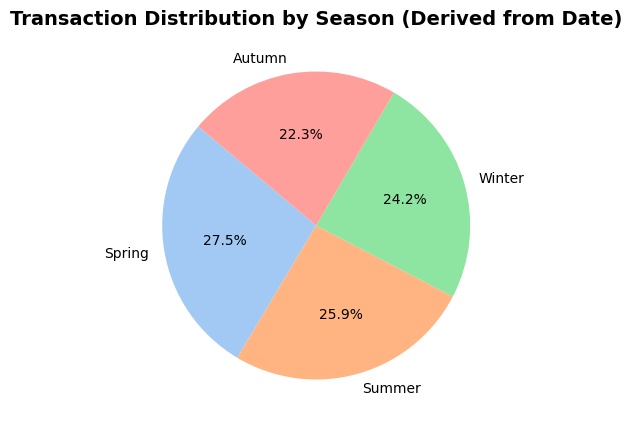

In [12]:
# THIẾT LẬP & LOAD RAW DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive', force_remount=True)
filter_path = '/content/drive/MyDrive/KLTN_dataset'

# Load Data
try:
    df_products = pd.read_csv(os.path.join(filter_path, 'apparel_products.csv'))
    df_clicks = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream.csv'))
    df_trans = pd.read_csv(os.path.join(filter_path, 'apparel_transactions.csv'))
    print("Load dữ liệu thành công!")
except FileNotFoundError:
    print("Lỗi đường dẫn. Hãy kiểm tra lại folder.")

# Lọc sự kiện Add-to-cart
df_cart = df_clicks[df_clicks['event_name'] == 'ADD_TO_CART'].copy()

# Kiểm tra tên cột ID trong clickstream để merge
click_id_col = 'product_id' # Mặc định
if 'product_id_extracted' in df_cart.columns:
    click_id_col = 'product_id_extracted'
elif 'product_id' in df_cart.columns:
    click_id_col = 'product_id'

print(f"Đang dùng cột '{click_id_col}' để merge.")

# Chuyển đổi sang số để merge không lỗi
df_cart[click_id_col] = pd.to_numeric(df_cart[click_id_col], errors='coerce')
df_products['product_id'] = pd.to_numeric(df_products['product_id'], errors='coerce')

# Merge
df_merged = df_cart.merge(df_products, left_on=click_id_col, right_on='product_id', how='inner')
print(f"Kích thước sau merge: {df_merged.shape}")


# 4. BIỂU ĐỒ 2: SEASONALITY (TÍNH TỪ GIAO DỊCH THỰC TẾ)

df_trans['created_at'] = pd.to_datetime(df_trans['created_at'])
df_trans['month'] = df_trans['created_at'].dt.month

# Map tháng sang mùa
season_map = {
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    12: 'Winter', 1: 'Winter', 2: 'Winter'
}
df_trans['season_derived'] = df_trans['month'].map(season_map)

plt.figure(figsize=(8, 5))
season_counts = df_trans['season_derived'].value_counts()
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140)
plt.title('Transaction Distribution by Season (Derived from Date)', fontsize=14, fontweight='bold')
plt.show()


Mounted at /content/drive
Đã trích xuất thành công 1182092 ID sản phẩm.
merge ok! Kích thước dữ liệu phân tích: (619581, 19)


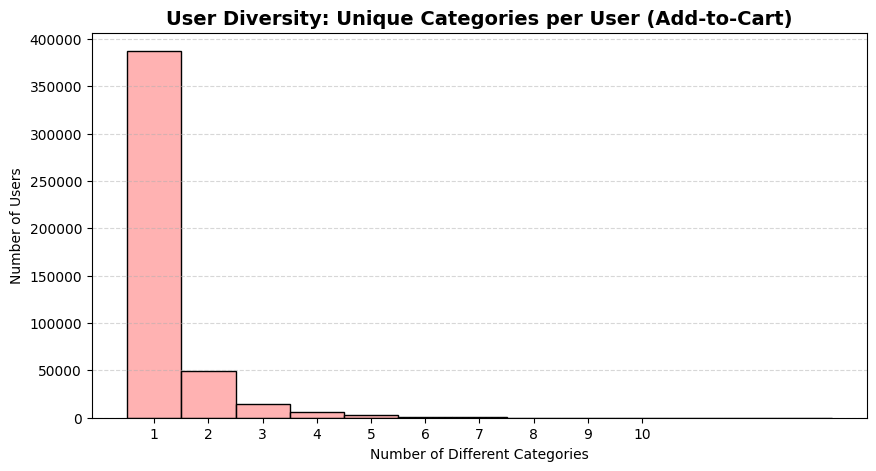

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from google.colab import drive

# SETUP
drive.mount('/content/drive', force_remount=True)
filter_path = '/content/drive/MyDrive/KLTN_dataset'

df_products = pd.read_csv(os.path.join(filter_path, 'apparel_products.csv'))
df_clicks = pd.read_csv(os.path.join(filter_path, 'apparel_clickstream.csv'))

# Chỉ lấy dòng ADD_TO_CART
df_cart = df_clicks[df_clicks['event_name'] == 'ADD_TO_CART'].copy()


# Hàm trích xuất dùng Regex (Tìm chữ 'product_id': theo sau là số)
def extract_id_from_metadata(text):
    if pd.isna(text):
        return np.nan
    # Tìm mẫu: 'product_id': <số>
    match = re.search(r"'product_id':\s*(\d+)", str(text))
    if match:
        return match.group(1) # Trả về con số tìm được (dạng chuỗi)
    return np.nan

# Áp dụng hàm
df_cart['extracted_id'] = df_cart['event_metadata'].apply(extract_id_from_metadata)

# Loại bỏ những dòng không tìm thấy ID
df_cart_clean = df_cart.dropna(subset=['extracted_id'])
print(f"Đã trích xuất thành công {len(df_cart_clean)} ID sản phẩm.")

# CHUẨN BỊ MERGE
# Chuyển hết về string
df_cart_clean['merge_key'] = df_cart_clean['extracted_id'].astype(str)

# Bên Product chuyển ID về string chuẩn
def clean_product_id(x):
    try:
        return str(int(float(x)))
    except:
        return str(x)

df_products['merge_key'] = df_products['product_id'].apply(clean_product_id)

# Merge
df_merged = df_cart_clean.merge(df_products, on='merge_key', how='inner')
print(f"merge ok! Kích thước dữ liệu phân tích: {df_merged.shape}")


if not df_merged.empty:
    user_col = 'customer_id' if 'customer_id' in df_merged.columns else 'session_id'
    cat_col = 'articleType' if 'articleType' in df_merged.columns else 'masterCategory'

    # BIỂU ĐỒ: USER DIVERSITY
    plt.figure(figsize=(10, 5))
    user_diversity = df_merged.groupby(user_col)[cat_col].nunique()

    # Vẽ
    sns.histplot(user_diversity, bins=np.arange(1, 12) - 0.5, discrete=True, color='#FF9999', edgecolor='black')
    plt.title(f'User Diversity: Unique Categories per User (Add-to-Cart)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Different Categories')
    plt.ylabel('Number of Users')
    plt.xticks(range(1, 11))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()